# Capture full power trace for P1P1t_times_O on STM32F4

## Capture setup

<font color='maroon'>&#10142; Capture device:</font> ChipWhisperer Husky</br>
<font color='maroon'>&#10142; Target board:</font> CW308 STM32F4</br>
<font color='maroon'>&#10142; Protocol:</font> SimpleSerial v2</br>

In [1]:
from pathlib import Path
import sys
import numpy as np

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / "data"

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import chipwhisperer as cw
from data.data import attack_O, attack_P2, attack_P1
import matplotlib.pyplot as plt

In [4]:
import chipwhisperer as cw
scope = cw.scope()

In [5]:
scope.default_setup()

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 131124                    to 5000                     
scope.adc.trig_count                     changed from 69                        to 10267810                 
scope.clock.clkgen_freq                  changed from 0                         to 7363636.363636363        
scope.clock.adc_freq                     changed from 0                         to 29454545.454545453       
scope.clock.adc_rate                     changed from 0.0                       to 29454545.454545453       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2      

In [6]:
target = cw.target(scope, cw.targets.SimpleSerial2)

## Select firmware variant to flash to the STM32F4 target

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Note:</strong> Select exactly one firmware image before running this cell. 
Uncomment the corresponding <code>cw.program_target(...)</code> block for either the unmasked or masked MAYO implementation, and keep the other block commented out. Adjust the firmware path if needed.
</div>

In [8]:
#unmasked capture
cw.program_target(
    scope,
    cw.programmers.STM32FProgrammer,
    "../../../firmware/mcu/simpleserial-mayo1nsstm/simpleserial-mayo1nsstm-CW308_STM32F4.hex"
)

#masked capture
#cw.program_target(
#    scope,
#    cw.programmers.STM32FProgrammer,
#    "../../firmware/mcu/simpleserial-mayo1masked/simpleserial-mayo1masked-CW308_STM32F4.hex"
#)

Detected known STMF32: STM32F40xxx/41xxx
Extended erase (0x44), this can take ten seconds or more
Attempting to program 128795 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 128795 bytes


<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Capture length:</strong> <code>scope.adc.samples</code> can be estimated from <code>scope.adc.trig_count</code> to capture the full trigger-high region. 
The commented value below matches the unmasked case and should be adjusted for masked captures.
</div>

In [13]:
scope.errors.clear()

scope.adc.stream_mode = True
scope.clock.adc_mul = 1  
scope.adc.samples = 14809374
scope.adc.timeout = 20

In [14]:
print(scope.errors)
print(scope.adc.errors)
print(scope.XADC.status)
scope.errors.clear()

sam_errors      = False
sam_led_setting = Default
XADC errors     = False
ADC errors      = False
extclk error    = False
trace errors    = False

False
good


In [15]:
scope.gain.db = 20

In [16]:
import time

# reset target
scope.io.nrst = 'low'
time.sleep(0.05)
scope.io.nrst = 'high_z'
time.sleep(0.1)

try:
    target.flush()
except Exception:
    pass

## Test simpleserial communication with target

<div class="alert alert-success" style="background-color: #eefaf1; color: #14532d; border-color: #bbf7d0;">
<strong>Expected result:</strong> Communication with the target is working correctly if <code>resp</code> returns <code>CWbytearray(b'99').</code>
</div>

In [17]:
msg = bytearray([0]*16)
target.simpleserial_write('t', b'')

In [18]:
resp = target.simpleserial_read('r', 1)
print(resp)

CWbytearray(b'99')


In [19]:
target.flush()

## Capture setup and data preload

In [20]:
scope.adc.basic_mode = "rising_edge"
scope.trigger.triggers = 'tio4'
V=78
OIL = 8
LIMBS=5

In [21]:
attack_O = np.array(attack_O, dtype=np.uint8)
attack_P2 = np.array(attack_P2, dtype=np.uint64)
O_bytes = bytes(attack_O)
P2_bytes = b''.join(int(x).to_bytes(8, 'little') for x in attack_P2)

chunk_size = 200   

for i in range(0, len(O_bytes), chunk_size):
    target.simpleserial_write('o', O_bytes[i:i+chunk_size])
    target.simpleserial_wait_ack()

print("O loaded.")

for i in range(0, len(P2_bytes), chunk_size):
    target.simpleserial_write('i', P2_bytes[i:i+chunk_size])
    target.simpleserial_wait_ack()

print("P2 loaded.")

O loaded.
P2 loaded.


## Single-trace capture during target function execution

In [22]:
target.flush()
scope.arm()
target.simpleserial_write('a', b'')
ret = scope.capture()

print("capture ret:", ret)
trace = scope.get_last_trace()

capture ret: False


In [23]:
resp = target.simpleserial_read('r', 1)
print("resp:", resp)

resp: CWbytearray(b'a5')


<div class="alert alert-warning" style="background-color: #fff8e6; color: #7a4f01; border-color: #ffe0a3;">
<strong>Save trace:</strong> The next cell saves the captured trace to <code>data_raw_trace.npy</code>. 
Change the filename or path if you want to keep multiple captures.
</div>

In [ ]:
np.save("data_raw_trace.npy", trace)

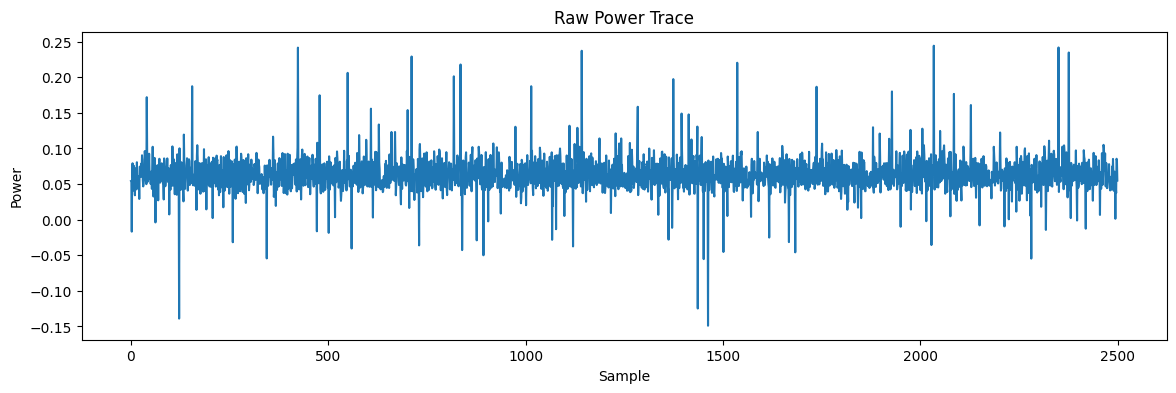

In [24]:
plt.figure(figsize=(14,4))
plt.plot(trace[0:2500])
plt.title("Raw Power Trace")
plt.xlabel("Sample")
plt.ylabel("Power")
plt.show()

## Average capture

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Averaging traces:</strong> Averaging several captures can reduce measurement noise and make it easier to identify the correct segment of the target function. 
For the unmasked implementation, the averaged trace can also be used directly in the attack. 
For the masked implementation, averaging is only useful for inspection and segmentation, not for the attack itself, because the shares are randomized for each execution.
</div>

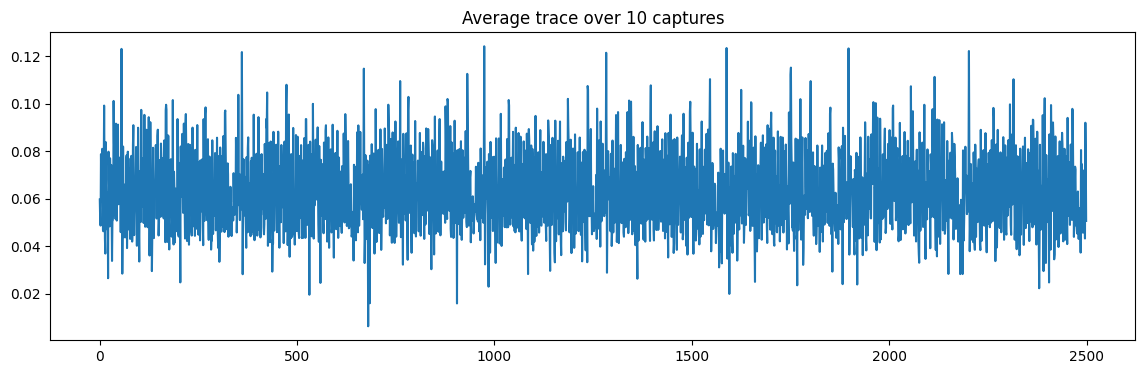

In [25]:
traces = []
num_captures = 10

for _ in range(num_captures):
    target.flush()
    scope.arm()
    target.simpleserial_write('a', b'')
    scope.capture()
    target.simpleserial_read('r', 1)
    traces.append(scope.get_last_trace())

traces = np.array(traces)
avg = np.mean(traces, axis=0)
avg_cropped = avg[0:2500]
plt.figure(figsize=(14,4))
plt.plot(avg_cropped)
plt.title(f"Average trace over {num_captures} captures")
plt.show()

# Segmentation

## Identify calls

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">

<strong>Template selection:</strong> The start and end indices below define the trace segment used as the template for the correlation scan. The goal is to select one target-function call as the template. 
A suitable template length can be estimated by dividing <code>scope.adc.trig_count</code>, which reports the number of ADC samples for which the trigger was high, by the total number of target-function calls in one capture. 
The expected total number of calls is <code>48048</code> for unmasked MAYO, <code>96096</code> for two-share masking and <code>144144</code> for three-share masking.

</div>

<Figure size 1400x400 with 0 Axes>

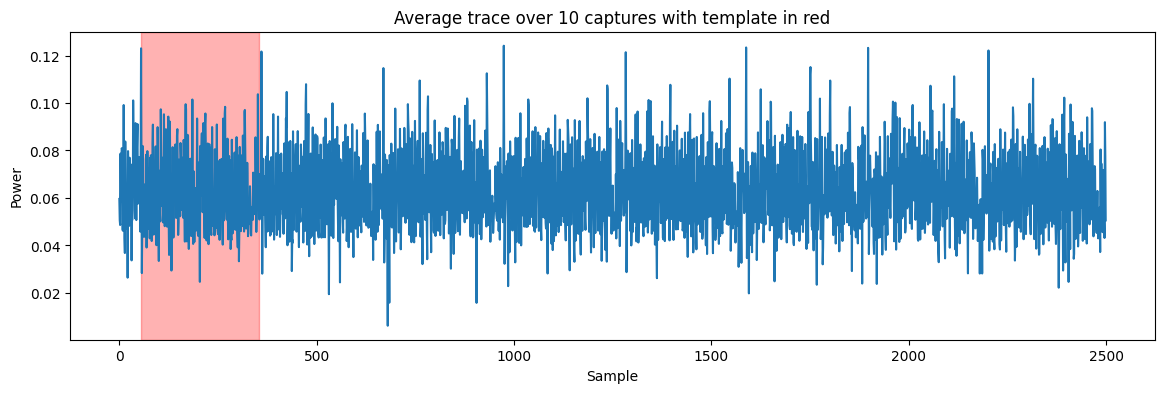

In [27]:
start= 0
window = 2500
seg = avg[start:start+window]


plt.figure(figsize=(14,4))
#template
start = 55
end = 355

plt.figure(figsize=(14,4))
plt.plot(seg)
plt.axvspan(start, end, color='red', alpha=0.3)
plt.title(f"Average trace over {num_captures} captures with template in red")
plt.xlabel("Sample")
plt.ylabel("Power")
plt.show()

## Correlation scan

In [30]:
template = avg[start:end]
template = (template - template.mean()) / template.std()

def normxcorr_1d(signal, template):
    signal = np.asarray(signal, dtype=float)
    m = len(template)
    out = np.empty(len(signal) - m + 1)
    for i in range(len(out)):
        w = signal[i:i+m]
        s = w.std()
        if s == 0:
            out[i] = 0
        else:
            w = (w - w.mean()) / s
            out[i] = np.dot(w, template) / m
    return out

corr = normxcorr_1d(avg, template)

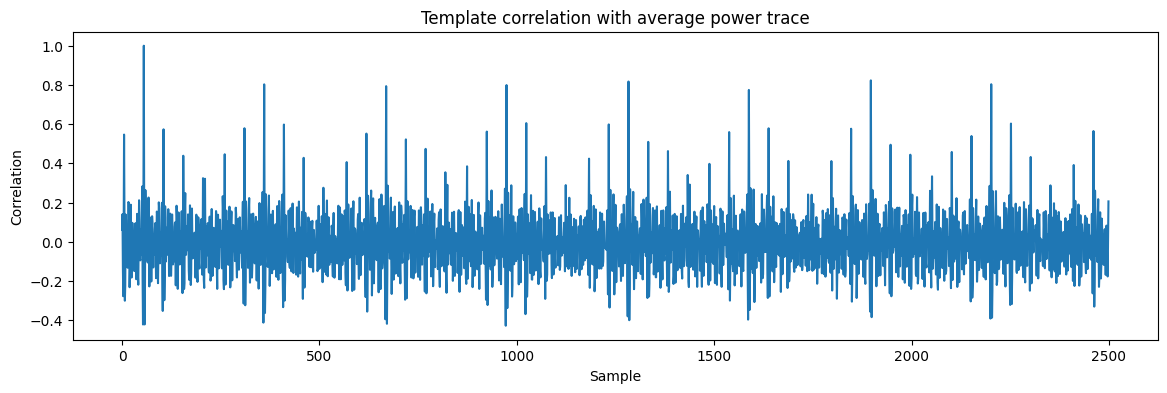

In [31]:
corr_crop = corr[0:2500]
plt.figure(figsize=(14,4))
plt.plot(corr_crop)
plt.title("Template correlation with average power trace")
plt.xlabel("Sample")
plt.ylabel("Correlation")
plt.show()

## Peak detection

<div class="alert alert-warning" style="background-color: #fff8e6; color: #7a4f01; border-color: #ffe0a3;">
<strong>Peak detection:</strong> Use the correlation plot above to estimate a suitable peak threshold. 
Set <code>height</code> to match the visible correlation peaks, and set <code>distance</code> to the number of samples in the template used for the correlation scan. 
If fewer peaks than expected are detected, lower the <code>height</code> value.
Expected peak counts are <code>48048</code> for unmasked MAYO, <code>96096</code> for two-share masking, and <code>144144</code> for three-share masking.
</div>

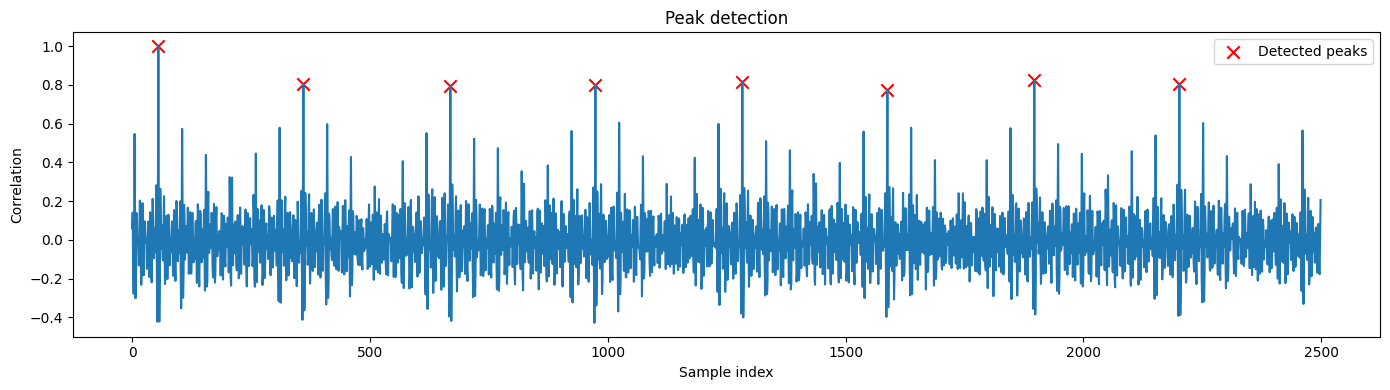

Number of identified peaks: 48048


In [40]:
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

peaks, _ = find_peaks(
    corr,
    height=0.6,
    distance=305
)

plt.figure(figsize=(14, 4))

plt.plot(corr_crop)
plt.scatter(
    peaks[:8],
    corr_crop[peaks[:8]],
    marker="x",
    color="red",
    s=80,
    label="Detected peaks"
)

plt.title("Peak detection")
plt.xlabel("Sample index")
plt.ylabel("Correlation")
plt.legend()
plt.tight_layout()
plt.show()

print("Number of identified peaks: " + str(len(peaks)))

<div class="alert alert-info" style="background-color: #eaf7fb; color: #1f2933; border-color: #b6e0ef;">
<strong>Save peaks:</strong> Run the cell below to save the detected peak indices for use in the attack notebook. These indices are loaded and used directly in the attack notebook.
</div>

In [41]:
np.save("peaks_unmasked.npy", peaks)
#np.save("peaks_masked_2shares.npy", peaks)
#np.save("peaks_masked_3shares.npy", peaks)

## Investigate segment lengths for later trace processing

In [38]:
distances = np.diff(peaks)

n_305 = np.sum(distances == 305)
n_309 = np.sum(distances == 309)
n_328 = np.sum(distances == 328)
n_348 = np.sum(distances == 348)
n_other = np.sum((distances != 305) & (distances != 309) & (distances != 328) & (distances != 348))

print("305:", n_305)
print("309:", n_309)
print("328:", n_328)
print("348:", n_348)
print("other:", n_other)

305: 24024
309: 21021
328: 2926
348: 76
other: 0


In [39]:
first_distances = np.diff(peaks[:100])
print(first_distances)

[305 309 305 309 305 309 305 309 305 309 305 309 305 309 305 328 305 309
 305 309 305 309 305 309 305 309 305 309 305 309 305 328 305 309 305 309
 305 309 305 309 305 309 305 309 305 309 305 328 305 309 305 309 305 309
 305 309 305 309 305 309 305 309 305 328 305 309 305 309 305 309 305 309
 305 309 305 309 305 309 305 328 305 309 305 309 305 309 305 309 305 309
 305 309 305 309 305 328 305 309 305]
